In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


## Methodological boundary before code execution

Notebook 19 must not be interpreted as a new aging mechanism branch.

The aging mechanism remains SEI-only. The diagnostic protocol changes from continuous low-rate discharge to pulse-rest reconstruction.

The extracted rest-end voltage is a finite-rest OCV-like descriptor. It is not strict thermodynamic OCV unless relaxation completeness is separately demonstrated.

The diagnostic branch must not be used to continue aging.

In [2]:
# Cell 2 — SEI-only OKane2022 model builder（SEI-only OKane2022 模型构建函数）

def build_sei_only_model():
    """
    Build DFN model with solvent-diffusion-limited SEI only.
    Other degradation mechanisms are disabled to keep the fingerprint source isolated.
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }
    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")
    return model, parameter_values


def make_solver():
    """Create a conservative CasADi solver for degradation-enabled DFN runs."""
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


model_smoke, pv_smoke = build_sei_only_model()

print("[OK] SEI-only OKane2022 DFN model instantiated.")
print("[MODEL]", model_smoke.name)

[OK] SEI-only OKane2022 DFN model instantiated.
[MODEL] Doyle-Fuller-Newman model


In [3]:
# Cell 3 — GITT-like protocol constants and audit design（GITT-like 协议常数与审计设计）

CHECKPOINT_CYCLES = [0, 20]

# Coarse GITT-like feasibility protocol
GITT_PULSE_RATE = "C/10"
GITT_PULSE_DURATION_MIN = 30
GITT_REST_DURATION_MIN = 60
GITT_N_PULSES = 16

# OKane2022 nominal capacity is about 5 Ah, so C/10 is about 0.5 A.
GITT_EXPECTED_CURRENT_A = 0.5
GITT_CURRENT_LO_A = 0.40
GITT_CURRENT_HI_A = 0.60

GITT_PULSE_DURATION_LO_MIN = 25
GITT_PULSE_DURATION_HI_MIN = 35
GITT_REST_DURATION_LO_MIN = 55
GITT_REST_DURATION_HI_MIN = 65

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

print("[CONFIG] checkpoints:", CHECKPOINT_CYCLES)
print("[CONFIG] GITT pulse rate:", GITT_PULSE_RATE)
print("[CONFIG] pulse duration min:", GITT_PULSE_DURATION_MIN)
print("[CONFIG] rest duration min:", GITT_REST_DURATION_MIN)
print("[CONFIG] number of pulses:", GITT_N_PULSES)
print("[OK] Protocol constants defined.")

[CONFIG] checkpoints: [0, 20]
[CONFIG] GITT pulse rate: C/10
[CONFIG] pulse duration min: 30
[CONFIG] rest duration min: 60
[CONFIG] number of pulses: 16
[OK] Protocol constants defined.


In [4]:
# Cell 4 — SEI-only aging checkpoint runner（SEI-only 老化检查点生成函数）

def make_aging_experiment(n_cycles, period="120 seconds"):
    """Build repeated SEI-only aging experiment."""
    if n_cycles == 0:
        return None
    return pybamm.Experiment([tuple(AGING_CYCLE_STEPS)] * n_cycles, period=period)


def run_aging_segment(n_cycles, starting_solution=None, initial_soc=None):
    """
    Run n_cycles of SEI-only aging.

    The returned solution is a pre-diagnostic aging state.
    Diagnostic branches must start from this solution, but must not be used
    to continue aging.
    """
    if n_cycles == 0:
        return starting_solution

    model, pv = build_sei_only_model()
    experiment = make_aging_experiment(n_cycles)
    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    if initial_soc is not None:
        kwargs["initial_soc"] = initial_soc

    sol = sim.solve(**kwargs)
    return sol


checkpoint_solutions = {0: None}

current_solution = None
current_cycle = 0

for target_cycle in CHECKPOINT_CYCLES[1:]:
    n_more = target_cycle - current_cycle
    print(f"[RUN] Aging from cycle {current_cycle} to {target_cycle} ({n_more} cycles)")
    current_solution = run_aging_segment(
        n_cycles=n_more,
        starting_solution=current_solution,
        initial_soc=1.0 if current_cycle == 0 else None,
    )
    checkpoint_solutions[target_cycle] = current_solution
    current_cycle = target_cycle
    print(f"[OK] checkpoint stored: {target_cycle} cycles")

print("[OK] Aging checkpoint generation complete.")
print("[CHECKPOINTS]", sorted(checkpoint_solutions.keys()))

[RUN] Aging from cycle 0 to 20 (20 cycles)
[OK] checkpoint stored: 20 cycles
[OK] Aging checkpoint generation complete.
[CHECKPOINTS] [0, 20]


In [5]:
# Cell 5 — GITT-like diagnostic branch runner（GITT-like 诊断分支运行函数）

def make_gitt_like_experiment(period="60 seconds"):
    """
    Build coarse GITT-like pulse-rest diagnostic protocol.

    The protocol intentionally avoids a lower-voltage cutoff in the pulse string
    to keep segment structure predictable in this first feasibility audit.
    The pulse count is limited so the diagnostic window remains above 2.5 V.
    """
    steps = []
    for _ in range(GITT_N_PULSES):
        steps.append(f"Discharge at {GITT_PULSE_RATE} for {GITT_PULSE_DURATION_MIN} minutes")
        steps.append(f"Rest for {GITT_REST_DURATION_MIN} minutes")

    return pybamm.Experiment(steps, period=period)


def run_gitt_like_diagnostic(cycle, starting_solution=None):
    """
    Run GITT-like diagnostic branch from a pre-diagnostic aging checkpoint.

    No repeated full-charge preconditioning is applied because the aging checkpoint
    already ends after charge-to-4.2V, CV hold, and 10 min rest.
    """
    model, pv = build_sei_only_model()
    experiment = make_gitt_like_experiment(period="60 seconds")

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    kwargs = {}
    if starting_solution is not None:
        kwargs["starting_solution"] = starting_solution
    else:
        kwargs["initial_soc"] = 1.0

    print(f"[RUN] GITT-like diagnostic branch: cycle={cycle}")
    sol = sim.solve(**kwargs)
    print(f"[OK] solved: cycle={cycle}")
    return sol


gitt_solutions = {}

for cycle in CHECKPOINT_CYCLES:
    gitt_solutions[cycle] = run_gitt_like_diagnostic(
        cycle=cycle,
        starting_solution=checkpoint_solutions[cycle],
    )

print("[OK] All GITT-like diagnostic branches solved.")
print("[N solutions]", len(gitt_solutions))

[RUN] GITT-like diagnostic branch: cycle=0
[OK] solved: cycle=0
[RUN] GITT-like diagnostic branch: cycle=20
[OK] solved: cycle=20
[OK] All GITT-like diagnostic branches solved.
[N solutions] 2


In [6]:
# Cell 6 — GITT-like segment audit and selected sequence extraction（GITT-like 分段审计与诊断序列提取）

def summarize_current_segments(sol, cycle, eps=1e-4):
    """
    Summarize sign-based current segments.

    PyBaMM sign convention:
    +I = discharge
    -I = charge
    near-zero = rest / cutoff
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    v = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "cycle": cycle,
            "segment_id": k,
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(v[a]),
            "U_end_V": float(v[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


all_segments = []
selected_rows = []

for cycle, sol in gitt_solutions.items():
    seg = summarize_current_segments(sol, cycle)
    all_segments.append(seg)

    pulse_candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"].between(GITT_CURRENT_LO_A, GITT_CURRENT_HI_A))
        & (seg["duration_min"].between(GITT_PULSE_DURATION_LO_MIN, GITT_PULSE_DURATION_HI_MIN))
    ].copy()

    if len(pulse_candidates) < GITT_N_PULSES:
        raise RuntimeError(
            f"Not enough GITT-like pulse candidates for cycle={cycle}: "
            f"found {len(pulse_candidates)}, expected {GITT_N_PULSES}"
        )

    # Select the last GITT_N_PULSES pulses to avoid aging history carried by starting_solution.
    selected_pulses = pulse_candidates.sort_values("t_start_s").tail(GITT_N_PULSES)

    for pulse_order, (_, pulse_row) in enumerate(selected_pulses.iterrows(), start=1):
        pulse_seg_id = int(pulse_row["segment_id"])

        # The rest segment should immediately follow the pulse segment.
        rest = seg[
            (seg["segment_id"] > pulse_seg_id)
            & (seg["segment_type"] == "rest")
            & (seg["duration_min"].between(GITT_REST_DURATION_LO_MIN, GITT_REST_DURATION_HI_MIN))
        ].sort_values("segment_id").head(1)

        if rest.empty:
            raise RuntimeError(f"No matching rest segment after pulse {pulse_seg_id} for cycle={cycle}")

        rest_row = rest.iloc[0]

        selected_rows.append({
            "cycle": cycle,
            "pulse_order": pulse_order,
            "pulse_segment_id": pulse_seg_id,
            "rest_segment_id": int(rest_row["segment_id"]),
            "pulse_idx_start": int(pulse_row["idx_start"]),
            "pulse_idx_stop": int(pulse_row["idx_stop"]),
            "rest_idx_start": int(rest_row["idx_start"]),
            "rest_idx_stop": int(rest_row["idx_stop"]),
            "pulse_duration_min": float(pulse_row["duration_min"]),
            "rest_duration_min": float(rest_row["duration_min"]),
            "pulse_I_mean_A": float(pulse_row["I_mean_A"]),
            "U_pulse_start_V": float(pulse_row["U_start_V"]),
            "U_pulse_end_V": float(pulse_row["U_end_V"]),
            "U_rest_start_V": float(rest_row["U_start_V"]),
            "U_rest_end_V": float(rest_row["U_end_V"]),
        })

segment_audit = pd.concat(all_segments, ignore_index=True)
selected_sequence_audit = pd.DataFrame(selected_rows)

segment_path = DATA / "gitt_like_ocv_segment_audit.csv"
selected_path = DATA / "gitt_like_ocv_selected_sequence_audit.csv"

segment_audit.to_csv(segment_path, index=False)
selected_sequence_audit.to_csv(selected_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {selected_path}")

display(selected_sequence_audit.groupby("cycle").agg(
    n_pulses=("pulse_order", "count"),
    pulse_I_mean_A=("pulse_I_mean_A", "mean"),
    pulse_duration_mean_min=("pulse_duration_min", "mean"),
    rest_duration_mean_min=("rest_duration_min", "mean"),
    U_first_rest_end_V=("U_rest_end_V", "first"),
    U_last_rest_end_V=("U_rest_end_V", "last"),
))

display(selected_sequence_audit.head())

assert selected_sequence_audit.groupby("cycle")["pulse_order"].count().eq(GITT_N_PULSES).all()
print("[OK] GITT-like selected pulse-rest sequences passed audit.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_selected_sequence_audit.csv


,n_pulses,pulse_I_mean_A,pulse_duration_mean_min,rest_duration_mean_min,U_first_rest_end_V,U_last_rest_end_V
cycle,,,,,,
0,16,0.5,30.0,60.0,4.122518,3.496030
20,16,0.5,30.0,60.0,4.120221,3.494346


,cycle,pulse_order,pulse_segment_id,rest_segment_id,pulse_idx_start,pulse_idx_stop,rest_idx_start,rest_idx_stop,pulse_duration_min,rest_duration_min,pulse_I_mean_A,U_pulse_start_V,U_pulse_end_V,U_rest_start_V,U_rest_end_V
0,0,1,0,1,0,31,31,92,30.0,60.0,0.5,4.176295,4.088665,4.109124,4.122518
1,0,2,2,3,92,123,123,184,30.0,60.0,0.5,4.101663,4.071659,4.090478,4.096251
2,0,3,4,5,184,215,215,276,30.0,60.0,0.5,4.077099,4.052723,4.070456,4.081054
3,0,4,6,7,276,307,307,368,30.0,60.0,0.5,4.063030,4.011425,4.028398,4.043030
4,0,5,8,9,368,399,399,460,30.0,60.0,0.5,4.025793,3.965079,3.981510,3.996276


[OK] GITT-like selected pulse-rest sequences passed audit.


In [7]:
# Cell 7 — Finite-rest OCV-like reconstruction point table（有限静置 OCV-like 重构点表）

def integrate_segment_charge_Ah(sol, idx_start, idx_stop):
    """
    Integrate positive discharge current over selected segment.
    PyBaMM convention: +I = discharge.
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    if len(t) < 2:
        return 0.0

    t_rel_h = (t - t[0]) / 3600.0
    dt_h = np.diff(t_rel_h)
    i_mid = 0.5 * (i[1:] + i[:-1])
    q_Ah = float(np.sum(i_mid * dt_h))
    return q_Ah


point_rows = []

for cycle, sol in gitt_solutions.items():
    selected = selected_sequence_audit[selected_sequence_audit["cycle"] == cycle].copy()
    selected = selected.sort_values("pulse_order").reset_index(drop=True)

    cumulative_Q_Ah = 0.0

    for _, row in selected.iterrows():
        pulse_idx_start = int(row["pulse_idx_start"])
        pulse_idx_stop = int(row["pulse_idx_stop"])
        rest_idx_start = int(row["rest_idx_start"])
        rest_idx_stop = int(row["rest_idx_stop"])

        pulse_Q_Ah = integrate_segment_charge_Ah(
            sol=sol,
            idx_start=pulse_idx_start,
            idx_stop=pulse_idx_stop,
        )

        cumulative_Q_Ah += pulse_Q_Ah

        pulse_drop_mV = (row["U_pulse_start_V"] - row["U_pulse_end_V"]) * 1000
        rest_recovery_mV = (row["U_rest_end_V"] - row["U_rest_start_V"]) * 1000
        net_relax_from_pulse_end_mV = (row["U_rest_end_V"] - row["U_pulse_end_V"]) * 1000

        point_rows.append({
            "cycle": int(cycle),
            "pulse_order": int(row["pulse_order"]),
            "pulse_Q_Ah": pulse_Q_Ah,
            "Q_cumulative_Ah": cumulative_Q_Ah,
            "U_pulse_start_V": float(row["U_pulse_start_V"]),
            "U_pulse_end_V": float(row["U_pulse_end_V"]),
            "U_rest_start_V": float(row["U_rest_start_V"]),
            "U_rest_end_V": float(row["U_rest_end_V"]),
            "U_finite_rest_ocv_like_V": float(row["U_rest_end_V"]),
            "pulse_drop_mV": float(pulse_drop_mV),
            "rest_recovery_mV": float(rest_recovery_mV),
            "net_relax_from_pulse_end_mV": float(net_relax_from_pulse_end_mV),
            "pulse_duration_min": float(row["pulse_duration_min"]),
            "rest_duration_min": float(row["rest_duration_min"]),
            "pulse_I_mean_A": float(row["pulse_I_mean_A"]),
        })

reconstruction_points = pd.DataFrame(point_rows)

point_path = DATA / "gitt_like_ocv_reconstruction_point_table.csv"
reconstruction_points.to_csv(point_path, index=False)

print(f"[OK] saved: {point_path}")
display(reconstruction_points.head())
display(reconstruction_points.groupby("cycle").agg(
    n_points=("pulse_order", "count"),
    Q_end_Ah=("Q_cumulative_Ah", "max"),
    U_first_rest_end_V=("U_finite_rest_ocv_like_V", "first"),
    U_last_rest_end_V=("U_finite_rest_ocv_like_V", "last"),
    mean_pulse_Q_Ah=("pulse_Q_Ah", "mean"),
    mean_rest_recovery_mV=("rest_recovery_mV", "mean"),
))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_reconstruction_point_table.csv


,cycle,pulse_order,pulse_Q_Ah,Q_cumulative_Ah,U_pulse_start_V,U_pulse_end_V,U_rest_start_V,U_rest_end_V,U_finite_rest_ocv_like_V,pulse_drop_mV,rest_recovery_mV,net_relax_from_pulse_end_mV,pulse_duration_min,rest_duration_min,pulse_I_mean_A
0,0,1,0.25,0.25,4.176295,4.088665,4.109124,4.122518,4.122518,87.629824,13.394099,33.853090,30.0,60.0,0.5
1,0,2,0.25,0.50,4.101663,4.071659,4.090478,4.096251,4.096251,30.004339,5.772889,24.592161,30.0,60.0,0.5
2,0,3,0.25,0.75,4.077099,4.052723,4.070456,4.081054,4.081054,24.375392,10.597765,28.330819,30.0,60.0,0.5
3,0,4,0.25,1.00,4.063030,4.011425,4.028398,4.043030,4.043030,51.604940,14.632279,31.605491,30.0,60.0,0.5
4,0,5,0.25,1.25,4.025793,3.965079,3.981510,3.996276,3.996276,60.714437,14.765933,31.196954,30.0,60.0,0.5


,n_points,Q_end_Ah,U_first_rest_end_V,U_last_rest_end_V,mean_pulse_Q_Ah,mean_rest_recovery_mV
cycle,,,,,,
0,16,4.0,4.122518,3.496030,0.25,12.089242
20,16,4.0,4.120221,3.494346,0.25,11.974609


In [8]:
# Cell 8 — GITT-like reconstruction quality audit（GITT-like 重构质量审计）

quality_rows = []

for cycle, g in reconstruction_points.groupby("cycle"):
    g = g.sort_values("pulse_order").reset_index(drop=True)

    q = g["Q_cumulative_Ah"].to_numpy()
    u = g["U_finite_rest_ocv_like_V"].to_numpy()
    recovery = g["rest_recovery_mV"].to_numpy()
    pulse_q = g["pulse_Q_Ah"].to_numpy()

    dQ = np.diff(q)
    dU = np.diff(u)

    n_points = len(g)
    q_end = float(q[-1])
    voltage_span = float(u[0] - u[-1])
    q_nonmono = int(np.sum(dQ <= 0))
    u_increase_count = int(np.sum(dU > 1e-5))
    u_increase_fraction = u_increase_count / max(len(dU), 1)

    pulse_Q_mean = float(np.mean(pulse_q))
    pulse_Q_cv_pct = float(np.std(pulse_q) / pulse_Q_mean * 100) if pulse_Q_mean != 0 else np.nan

    recovery_positive_fraction = float(np.mean(recovery > 0))

    pass_quality = (
        n_points == GITT_N_PULSES
        and q_end > 3.5
        and voltage_span > 0.5
        and q_nonmono == 0
        and u_increase_fraction == 0
        and pulse_Q_cv_pct < 1.0
        and recovery_positive_fraction > 0.9
    )

    quality_rows.append({
        "cycle": int(cycle),
        "n_points": n_points,
        "Q_end_Ah": q_end,
        "U_first_rest_end_V": float(u[0]),
        "U_last_rest_end_V": float(u[-1]),
        "voltage_span_V": voltage_span,
        "Q_nonmonotonic_count": q_nonmono,
        "U_rest_end_increase_count": u_increase_count,
        "U_rest_end_increase_fraction": u_increase_fraction,
        "pulse_Q_mean_Ah": pulse_Q_mean,
        "pulse_Q_cv_pct": pulse_Q_cv_pct,
        "rest_recovery_positive_fraction": recovery_positive_fraction,
        "rest_recovery_mean_mV": float(np.mean(recovery)),
        "rest_recovery_min_mV": float(np.min(recovery)),
        "rest_recovery_max_mV": float(np.max(recovery)),
        "pass_reconstruction_quality": pass_quality,
    })

quality_audit = pd.DataFrame(quality_rows)

quality_path = DATA / "gitt_like_ocv_quality_audit.csv"
quality_audit.to_csv(quality_path, index=False)

print(f"[OK] saved: {quality_path}")
display(quality_audit)

assert quality_audit["pass_reconstruction_quality"].all(), "GITT-like reconstruction quality failed."

print("[OK] GITT-like finite-rest OCV reconstruction quality passed.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_quality_audit.csv


,cycle,n_points,Q_end_Ah,U_first_rest_end_V,U_last_rest_end_V,voltage_span_V,Q_nonmonotonic_count,U_rest_end_increase_count,U_rest_end_increase_fraction,pulse_Q_mean_Ah,pulse_Q_cv_pct,rest_recovery_positive_fraction,rest_recovery_mean_mV,rest_recovery_min_mV,rest_recovery_max_mV,pass_reconstruction_quality
0,0,16,4.0,4.122518,3.496030,0.626488,0,0,0.0,0.25,2.556679e-13,1.0,12.089242,5.772889,14.815692,True
1,20,16,4.0,4.120221,3.494346,0.625874,0,0,0.0,0.25,1.265338e-12,1.0,11.974609,5.952118,14.919973,True


[OK] GITT-like finite-rest OCV reconstruction quality passed.


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_0_vs_20_comparison_table.csv


,pulse_order,Q_0cycle_Ah,Q_20cycle_Ah,Q_mean_Ah,U_0cycle_V,U_20cycle_V,deltaU_20_minus_0_mV,recovery_0cycle_mV,recovery_20cycle_mV,delta_recovery_20_minus_0_mV
0,1,0.25,0.25,0.25,4.122518,4.120221,-2.297808,13.394099,13.101539,-0.292560
1,2,0.50,0.50,0.50,4.096251,4.096184,-0.067413,5.772889,5.952118,0.179229
2,3,0.75,0.75,0.75,4.081054,4.079932,-1.121913,10.597765,11.111741,0.513976
3,4,1.00,1.00,1.00,4.043030,4.041373,-1.657832,14.632279,14.728170,0.095891
4,5,1.25,1.25,1.25,3.996276,3.994368,-1.907707,14.765933,14.609306,-0.156627


,deltaU_20_minus_0_mV,delta_recovery_20_minus_0_mV
mean,-1.973808,-0.114633
median,-2.054105,-0.133541
min,-3.025508,-0.629861
max,-0.067413,0.513976


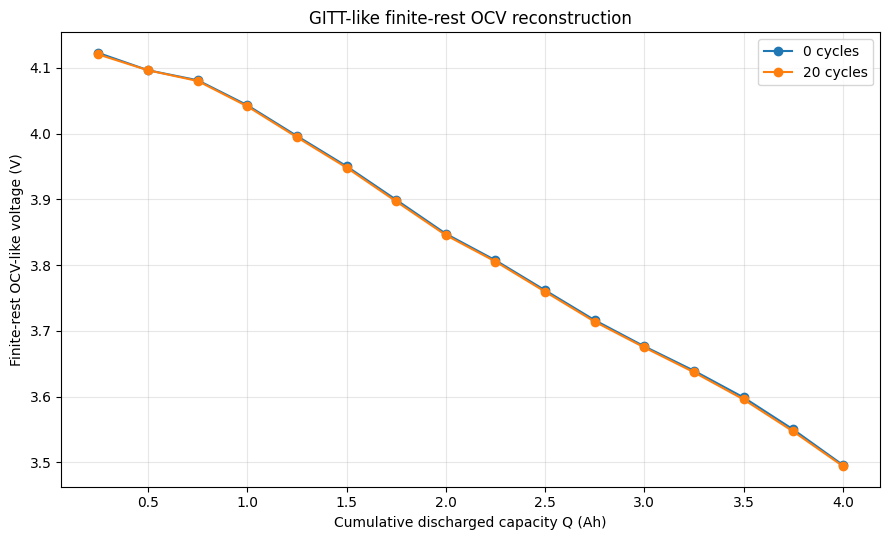

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/gitt_like_ocv_reconstruction_overlay.png


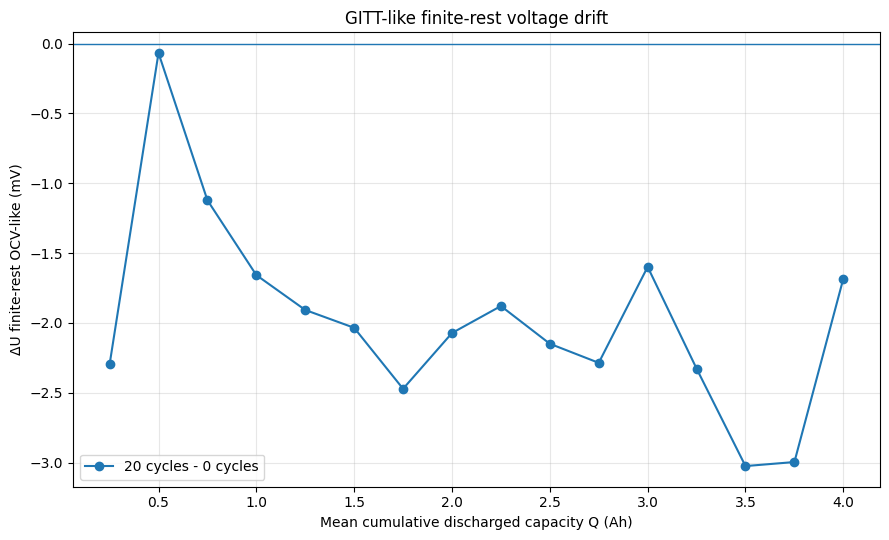

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/gitt_like_ocv_deltaU_vs_Q.png


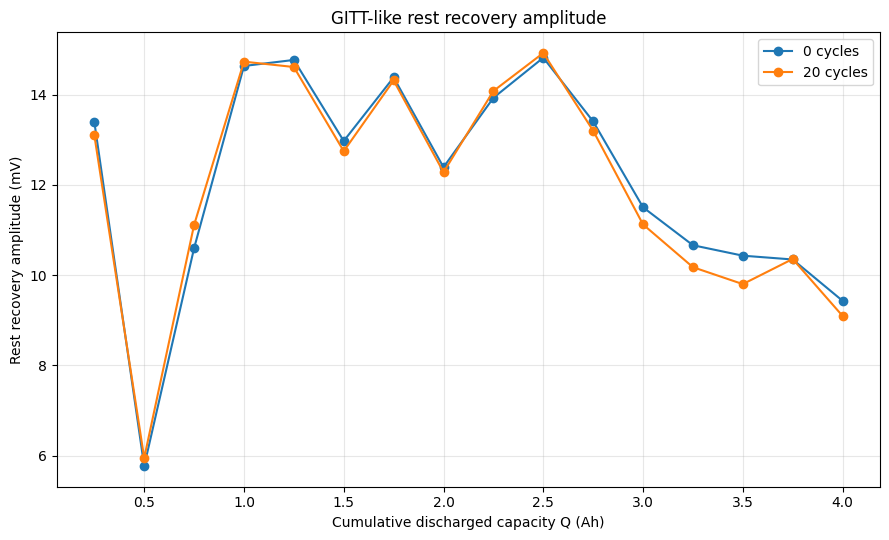

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/gitt_like_ocv_recovery_amplitude.png


In [9]:
# Cell 9 — GITT-like OCV reconstruction comparison and figures（GITT-like OCV 重构比较与图像）

# Direct pulse-order comparison
base = reconstruction_points[reconstruction_points["cycle"] == 0].copy()
aged = reconstruction_points[reconstruction_points["cycle"] == 20].copy()

base = base.sort_values("pulse_order").reset_index(drop=True)
aged = aged.sort_values("pulse_order").reset_index(drop=True)

comparison = pd.DataFrame({
    "pulse_order": base["pulse_order"],
    "Q_0cycle_Ah": base["Q_cumulative_Ah"],
    "Q_20cycle_Ah": aged["Q_cumulative_Ah"],
    "Q_mean_Ah": 0.5 * (base["Q_cumulative_Ah"] + aged["Q_cumulative_Ah"]),
    "U_0cycle_V": base["U_finite_rest_ocv_like_V"],
    "U_20cycle_V": aged["U_finite_rest_ocv_like_V"],
    "deltaU_20_minus_0_mV": (
        aged["U_finite_rest_ocv_like_V"].to_numpy()
        - base["U_finite_rest_ocv_like_V"].to_numpy()
    ) * 1000,
    "recovery_0cycle_mV": base["rest_recovery_mV"],
    "recovery_20cycle_mV": aged["rest_recovery_mV"],
    "delta_recovery_20_minus_0_mV": (
        aged["rest_recovery_mV"].to_numpy()
        - base["rest_recovery_mV"].to_numpy()
    ),
})

comparison_path = DATA / "gitt_like_ocv_0_vs_20_comparison_table.csv"
comparison.to_csv(comparison_path, index=False)

print(f"[OK] saved: {comparison_path}")
display(comparison.head())
display(comparison.agg({
    "deltaU_20_minus_0_mV": ["mean", "median", "min", "max"],
    "delta_recovery_20_minus_0_mV": ["mean", "median", "min", "max"],
}))

# Figure 1 — finite-rest OCV-like reconstruction overlay
plt.figure(figsize=(9, 5.5))
for cycle, g in reconstruction_points.groupby("cycle"):
    plt.plot(
        g["Q_cumulative_Ah"],
        g["U_finite_rest_ocv_like_V"],
        marker="o",
        label=f"{cycle} cycles"
    )
plt.xlabel("Cumulative discharged capacity Q (Ah)")
plt.ylabel("Finite-rest OCV-like voltage (V)")
plt.title("GITT-like finite-rest OCV reconstruction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "gitt_like_ocv_reconstruction_overlay.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — delta U vs Q
plt.figure(figsize=(9, 5.5))
plt.plot(
    comparison["Q_mean_Ah"],
    comparison["deltaU_20_minus_0_mV"],
    marker="o",
    label="20 cycles - 0 cycles"
)
plt.axhline(0, linewidth=1)
plt.xlabel("Mean cumulative discharged capacity Q (Ah)")
plt.ylabel("ΔU finite-rest OCV-like (mV)")
plt.title("GITT-like finite-rest voltage drift")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "gitt_like_ocv_deltaU_vs_Q.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — recovery amplitude
plt.figure(figsize=(9, 5.5))
for cycle, g in reconstruction_points.groupby("cycle"):
    plt.plot(
        g["Q_cumulative_Ah"],
        g["rest_recovery_mV"],
        marker="o",
        label=f"{cycle} cycles"
    )
plt.xlabel("Cumulative discharged capacity Q (Ah)")
plt.ylabel("Rest recovery amplitude (mV)")
plt.title("GITT-like rest recovery amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
p = FIGURES / "gitt_like_ocv_recovery_amplitude.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

In [10]:
# Cell 10 — GITT-like OCV reconstruction classification（GITT-like OCV 重构分类）

all_quality_pass = bool(quality_audit["pass_reconstruction_quality"].all())

mean_deltaU_mV = float(comparison["deltaU_20_minus_0_mV"].mean())
median_deltaU_mV = float(comparison["deltaU_20_minus_0_mV"].median())
max_abs_deltaU_mV = float(np.max(np.abs(comparison["deltaU_20_minus_0_mV"])))

mean_recovery_shift_mV = float(comparison["delta_recovery_20_minus_0_mV"].mean())
max_abs_recovery_shift_mV = float(np.max(np.abs(comparison["delta_recovery_20_minus_0_mV"])))

q_end_min = float(quality_audit["Q_end_Ah"].min())
u_span_min = float(quality_audit["voltage_span_V"].min())

# Conservative feasibility classification
if all_quality_pass and q_end_min > 3.5 and u_span_min > 0.5:
    strength = "feasibility supported"
    verdict = "GITT-like finite-rest OCV reconstruction is technically feasible"
else:
    strength = "deferred"
    verdict = "GITT-like finite-rest OCV reconstruction requires protocol revision"

classification_rows = [
    {
        "metric_layer": "segment_quality",
        "evidence": f"Each checkpoint produced {GITT_N_PULSES} valid C/10 pulse-rest pairs.",
        "strength": "strong",
        "classification": "GITT-like pulse-rest segmentation is technically clean",
    },
    {
        "metric_layer": "reconstruction_quality",
        "evidence": f"All reconstruction quality checks passed = {all_quality_pass}",
        "strength": "strong" if all_quality_pass else "insufficient",
        "classification": "finite-rest OCV-like points are smooth and monotonic" if all_quality_pass else "finite-rest reconstruction deferred",
    },
    {
        "metric_layer": "voltage_drift",
        "evidence": f"20-cycle minus 0-cycle finite-rest voltage drift: mean = {mean_deltaU_mV:.3f} mV, median = {median_deltaU_mV:.3f} mV, max abs = {max_abs_deltaU_mV:.3f} mV",
        "strength": "data-backed",
        "classification": "aging-related finite-rest voltage drift is quantifiable",
    },
    {
        "metric_layer": "recovery_amplitude",
        "evidence": f"Recovery amplitude shift: mean = {mean_recovery_shift_mV:.3f} mV, max abs = {max_abs_recovery_shift_mV:.3f} mV",
        "strength": "audit-level",
        "classification": "rest recovery amplitude provides an auxiliary relaxation descriptor",
    },
    {
        "metric_layer": "boundary",
        "evidence": "Rest-end voltage after 60 min is finite-rest OCV-like, not strict thermodynamic OCV.",
        "strength": "methodological boundary",
        "classification": "strict OCV remains unproven without longer rest or GITT validation branch",
    },
    {
        "metric_layer": "overall",
        "evidence": "Coarse C/10 pulse-rest protocol produced interpretable finite-rest OCV-like reconstruction points at 0 and 20 cycles.",
        "strength": strength,
        "classification": verdict,
    },
]

classification_table = pd.DataFrame(classification_rows)

classification_path = DATA / "gitt_like_ocv_classification_table.csv"
classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_classification_table.csv


,metric_layer,evidence,strength,classification
0,segment_quality,Each checkpoint produced 16 valid C/10 pulse-r...,strong,GITT-like pulse-rest segmentation is technical...
1,reconstruction_quality,All reconstruction quality checks passed = True,strong,finite-rest OCV-like points are smooth and mon...
2,voltage_drift,20-cycle minus 0-cycle finite-rest voltage dri...,data-backed,aging-related finite-rest voltage drift is qua...
3,recovery_amplitude,"Recovery amplitude shift: mean = -0.115 mV, ma...",audit-level,rest recovery amplitude provides an auxiliary ...
4,boundary,Rest-end voltage after 60 min is finite-rest O...,methodological boundary,strict OCV remains unproven without longer res...
5,overall,Coarse C/10 pulse-rest protocol produced inter...,feasibility supported,GITT-like finite-rest OCV reconstruction is te...


In [11]:
# Cell 11 — Output inventory audit（输出文件清单审计）

expected_outputs = [
    DATA / "gitt_like_ocv_segment_audit.csv",
    DATA / "gitt_like_ocv_selected_sequence_audit.csv",
    DATA / "gitt_like_ocv_reconstruction_point_table.csv",
    DATA / "gitt_like_ocv_quality_audit.csv",
    DATA / "gitt_like_ocv_0_vs_20_comparison_table.csv",
    DATA / "gitt_like_ocv_classification_table.csv",
    FIGURES / "gitt_like_ocv_reconstruction_overlay.png",
    FIGURES / "gitt_like_ocv_deltaU_vs_Q.png",
    FIGURES / "gitt_like_ocv_recovery_amplitude.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "gitt_like_ocv_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected output files are missing."
print("[OK] All expected Notebook 19 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/gitt_like_ocv_output_inventory.csv


,path,exists,size_kB
0,data/gitt_like_ocv_segment_audit.csv,True,19.54
1,data/gitt_like_ocv_selected_sequence_audit.csv,True,4.66
2,data/gitt_like_ocv_reconstruction_point_table.csv,True,7.38
3,data/gitt_like_ocv_quality_audit.csv,True,0.68
4,data/gitt_like_ocv_0_vs_20_comparison_table.csv,True,2.84
5,data/gitt_like_ocv_classification_table.csv,True,1.05
6,figures/gitt_like_ocv_reconstruction_overlay.png,True,165.05
7,figures/gitt_like_ocv_deltaU_vs_Q.png,True,162.51
8,figures/gitt_like_ocv_recovery_amplitude.png,True,212.30


[OK] All expected Notebook 19 outputs exist.


## Final closure — Notebook 19

### Key findings

Notebook 19 audited whether a GITT-like pulse-rest diagnostic protocol can reconstruct finite-rest OCV-like voltage points from the SEI-only aging branch.

The diagnostic protocol used repeated C/10 discharge pulses followed by 60 min rest periods. Each diagnostic branch contained 16 pulse-rest pairs. Each pulse discharged approximately 0.25 Ah, resulting in a reconstructed finite-rest OCV-like curve over a cumulative discharge window of approximately 4.0 Ah.

The selected pulse-rest sequences passed the segment-level audit at both checkpoints:

- 0 cycles,
- 20 cycles.

Each checkpoint produced 16 valid C/10 pulse-rest pairs with:

- mean pulse current ≈ 0.5 A,
- pulse duration = 30 min,
- rest duration = 60 min,
- cumulative reconstructed Q-window = 4.0 Ah.

The finite-rest reconstruction quality audit passed. The reconstructed rest-end voltage points were monotonic with cumulative discharged capacity, Q was strictly increasing, pulse charge was highly consistent, and the rest recovery amplitude remained positive for all pulse-rest pairs.

The finite-rest OCV-like reconstruction shows a weak but consistent aging-related voltage shift. Relative to the 0-cycle reference, the 20-cycle curve is slightly lower over the reconstructed Q-window:

- mean ΔU(20 cycles − 0 cycles) ≈ −1.974 mV,
- median ΔU ≈ −2.054 mV,
- minimum ΔU ≈ −3.026 mV,
- maximum ΔU ≈ −0.067 mV.

The recovery-amplitude shift is very small:

- mean Δrecovery(20 cycles − 0 cycles) ≈ −0.115 mV,
- maximum absolute recovery shift ≈ 0.630 mV.

This indicates that the GITT-like finite-rest voltage reconstruction can resolve a weak voltage drift under SEI-only aging, while rest-recovery amplitude remains an auxiliary and weak descriptor.

### Interpretation boundary

This notebook establishes technical feasibility of GITT-like finite-rest OCV reconstruction. It does not establish strict thermodynamic OCV.

The extracted rest-end voltage after 60 min rest should be described as a finite-rest OCV-like descriptor. Although the pulse-rest protocol reduces polarization effects compared with continuous low-rate discharge, complete relaxation is not proven.

The diagnostic protocol is also intentionally coarse:

- C/10 pulse current,
- 30 min pulse duration,
- 60 min rest,
- 0.25 Ah capacity step per pulse,
- 16 reconstructed points,
- cumulative Q-window of approximately 4.0 Ah.

Therefore, the output is suitable for feasibility-level quasi-equilibrium reconstruction, but not for final high-resolution OCV-SOC or ICA/DVA mechanism attribution.

### Correct conclusion wording

Supported:

- The GITT-like pulse-rest segmentation is technically clean.
- Finite-rest OCV-like reconstruction points are smooth and monotonic.
- A weak, consistent 20-cycle voltage drift relative to the 0-cycle reference is quantifiable.
- Rest-recovery amplitude can be extracted as an auxiliary relaxation descriptor.
- GITT-like finite-rest reconstruction is technically feasible for the SEI-only branch.

Not supported:

- This notebook does not prove strict thermodynamic OCV.
- The 60 min rest-end voltage is not guaranteed to be fully relaxed equilibrium voltage.
- The coarse 0.25 Ah step size is not sufficient for high-resolution ICA/DVA.
- This notebook does not establish a mechanism-unique SEI fingerprint.
- This notebook does not replace slower or more rigorous GITT / quasi-equilibrium protocols.

### Classification

`GITT-like finite-rest OCV reconstruction = feasibility supported`

Project-level wording:

> A coarse C/10 pulse-rest protocol can reconstruct smooth and monotonic finite-rest OCV-like points in the SEI-only aging branch. The method is technically feasible and provides a weak voltage-drift descriptor, but strict thermodynamic OCV remains unproven.

### Next step

The next step is to commit Notebook 19 and then consolidate representative outputs into the documentation layer.

Further technical extensions can include:

1. longer rest-duration validation, e.g. 60 min vs 120 min;
2. smaller pulse steps for higher-resolution OCV reconstruction;
3. comparison between continuous C/50 and GITT-like finite-rest reconstruction on a common Q-grid;
4. stronger aging checkpoints to test whether the weak voltage drift becomes more separable;
5. plating or LAM mechanism branches to determine whether GITT-like voltage reconstruction becomes mechanism-discriminative.